In [1]:
import os
import librosa
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt

# 1. SoundWave - ADSR - Spectoegram

In [2]:
def estimate_adsr_boundaries(rms_norm, times, threshold=0.01):
    """
    Ước lượng các mốc thời gian t_start, t_peak, t_decay_end, t_release_start, t_end
    dựa trên đường bao RMS đã chuẩn hóa.
    """
    # 1. Tìm Peak (Đỉnh Attack / Bắt đầu Decay)
    peak_idx = np.argmax(rms_norm)
    
    # 2. Tìm điểm bắt đầu (Attack start)
    valid_starts = np.where(rms_norm[:peak_idx] >= threshold)[0]
    start_idx = valid_starts[0] if len(valid_starts) > 0 else 0
    
    # 3. Tìm điểm kết thúc (Release end)
    valid_ends = np.where(rms_norm[peak_idx:] >= threshold)[0]
    end_idx = peak_idx + valid_ends[-1] if len(valid_ends) > 0 else len(rms_norm) - 1
    
    # 4. Xác định vùng Sustain (Đoạn biên độ biến thiên chậm nhất sau đỉnh)
    post_peak_rms = rms_norm[peak_idx:end_idx]
    if len(post_peak_rms) > 4:
        gradients = np.abs(np.gradient(post_peak_rms))
        min_grad_idx = peak_idx + np.argmin(gradients)
        decay_end_idx = peak_idx + (min_grad_idx - peak_idx) // 2
        release_start_idx = min_grad_idx + (end_idx - min_grad_idx) // 2
    else:
        decay_end_idx = peak_idx + (end_idx - peak_idx) // 3
        release_start_idx = peak_idx + 2 * (end_idx - peak_idx) // 3
        
    return (
        times[start_idx],
        times[peak_idx],
        times[decay_end_idx],
        times[release_start_idx],
        times[end_idx]
    )

def plot_mp3_adsr_with_spectrogram(file_path):
    """
    Load file MP3, vẽ Waveform (kèm phân vùng ADSR) ở trên và Spectrogram ở dưới.
    """
    # 1. Load file âm thanh
    y, sr = librosa.load(file_path, sr=None)
    
    # 2. Tính toán đường bao RMS (Envelope) & mốc ADSR
    hop_length = 512
    frame_length = 2048
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    rms_norm = rms / np.max(rms) if np.max(rms) > 0 else rms
    times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)
    
    t_start, t_peak, t_sustain_start, t_release_start, t_end = estimate_adsr_boundaries(rms_norm, times)
    
    # 3. Tính toán Spectrogram (STFT -> Decibel)
    D = librosa.stft(y, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    
    # 4. Khởi tạo Figure gồm 2 hàng x 1 cột (chia sẻ chung trục hoành thời gian sharex=True)
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), sharex=True)
    
    # ==========================================
    # ĐỒ THỊ 1 (ĐỈNH): WAVEFORM & CÁC VÙNG ADSR
    # ==========================================
    # Vẽ Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0], alpha=0.4, color='gray', label='Waveform')
    
    # Vẽ đường bao RMS
    max_amp = np.max(np.abs(y))
    ax[0].plot(times, rms_norm * max_amp, color='black', linewidth=1.5, linestyle='--', label='RMS Envelope')
    
    # Tô màu 4 vùng ADSR
    ax[0].axvspan(t_start, t_peak, color='red', alpha=0.3, 
                  label=f'Attack ({t_start:.2f}s - {t_peak:.2f}s)')
    ax[0].axvspan(t_peak, t_sustain_start, color='orange', alpha=0.3, 
                  label=f'Decay ({t_peak:.2f}s - {t_sustain_start:.2f}s)')
    ax[0].axvspan(t_sustain_start, t_release_start, color='green', alpha=0.3, 
                  label=f'Sustain ({t_sustain_start:.2f}s - {t_release_start:.2f}s)')
    ax[0].axvspan(t_release_start, t_end, color='purple', alpha=0.3, 
                  label=f'Release ({t_release_start:.2f}s - {t_end:.2f}s)')
    
    ax[0].set(title='PHÂN TÍCH ADSR VÀ SPECTROGRAM ÂM THANH', ylabel='Biên độ (Amplitude)')
    ax[0].legend(loc='upper right', fontsize='small')
    ax[0].grid(True, linestyle='--', alpha=0.4)
    
    # ==========================================
    # ĐỒ THỊ 2 (DƯỚI): SPECTROGRAM
    # ==========================================
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, 
                                   x_axis='time', y_axis='log', ax=ax[1], cmap='magma')
    
    # Vẽ các đường ranh giới ADSR đứng trên Spectrogram để dễ dóng hàng đối chiếu
    boundaries = [t_start, t_peak, t_sustain_start, t_release_start, t_end]
    boundary_colors = ['red', 'orange', 'green', 'purple', 'gray']
    
    for b_time, color in zip(boundaries, boundary_colors):
        ax[1].axvline(x=b_time, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
        
    ax[1].set(xlabel='Thời gian (giây)', ylabel='Tần số (Hz)')
    
    # Thêm thanh màu (Colorbar) thể hiện cường độ dB
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
    
    plt.tight_layout()
    plt.show()

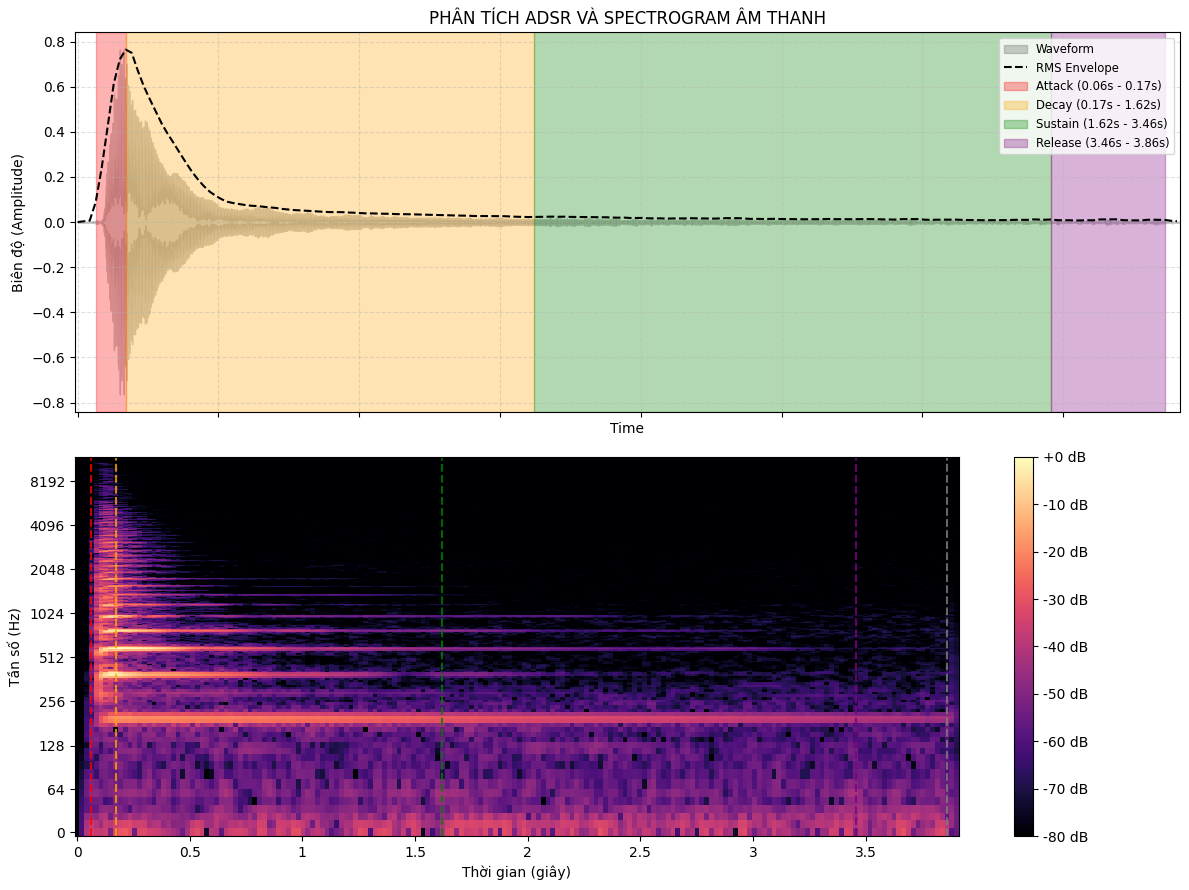

In [3]:
plot_mp3_adsr_with_spectrogram(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3")

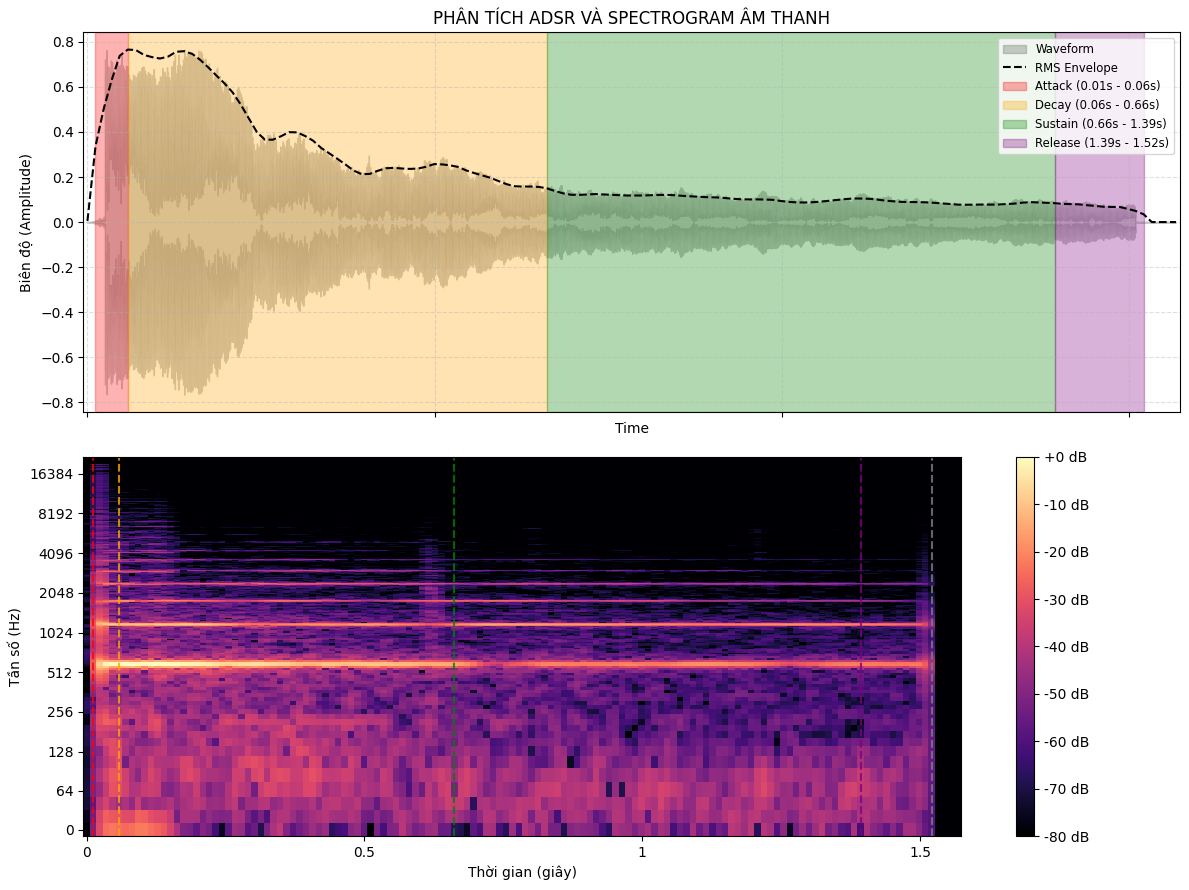

In [4]:
plot_mp3_adsr_with_spectrogram(r"E:\s-recognition\data\u_df365hdxp7-cinematic-piano-note-362716.mp3")

# 2. Timbre - Complex sound

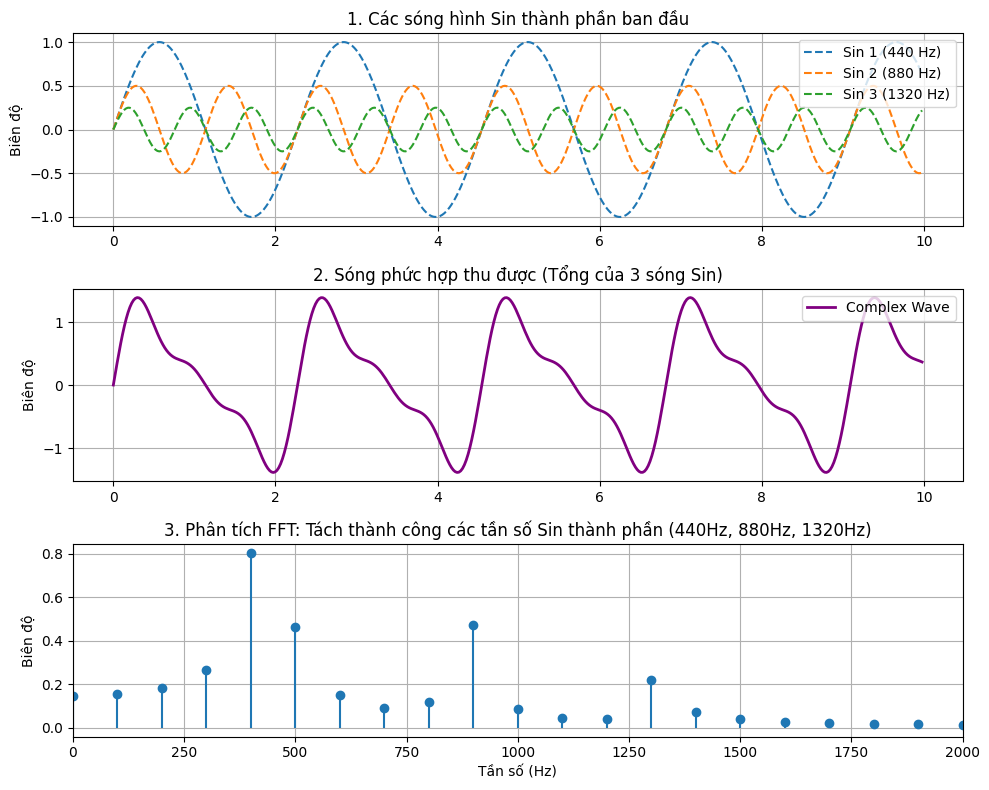

In [5]:
# 1. Cấu hình tham số thời gian
sr = 44100       # Sample rate (Hz)
duration = 0.01  # Khoảng thời gian ngắn (0.01s) để dễ quan sát sóng
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# 2. Tạo 3 sóng hình Sin cơ bản với biên độ và tần số khác nhau
sin1 = 1.0 * np.sin(2 * np.pi * 440 * t)   # Sóng 1: 440 Hz (Nốt La / A4)
sin2 = 0.5 * np.sin(2 * np.pi * 880 * t)   # Sóng 2: 880 Hz (Họa âm 1)
sin3 = 0.25 * np.sin(2 * np.pi * 1320 * t) # Sóng 3: 1320 Hz (Họa âm 2)

# Sóng phức hợp = Tổng các sóng sin cộng lại
complex_wave = sin1 + sin2 + sin3

# 3. Phân tách bằng Biến đổi Fourier (FFT)
fft_spectrum = np.fft.rfft(complex_wave)
freqs = np.fft.rfftfreq(len(complex_wave), d=1/sr)
amplitudes = np.abs(fft_spectrum) / len(complex_wave) * 2

# 4. Trực quan hóa
fig, ax = plt.subplots(3, 1, figsize=(10, 8))

# Đồ thị 1: 3 sóng Sin thành phần
ax[0].plot(t * 1000, sin1, label='Sin 1 (440 Hz)', linestyle='--')
ax[0].plot(t * 1000, sin2, label='Sin 2 (880 Hz)', linestyle='--')
ax[0].plot(t * 1000, sin3, label='Sin 3 (1320 Hz)', linestyle='--')
ax[0].set(title='1. Các sóng hình Sin thành phần ban đầu', ylabel='Biên độ')
ax[0].legend(loc='upper right')
ax[0].grid(True)

# Đồ thị 2: Sóng phức hợp sau khi cộng gộp
ax[1].plot(t * 1000, complex_wave, color='purple', linewidth=2, label='Complex Wave')
ax[1].set(title='2. Sóng phức hợp thu được (Tổng của 3 sóng Sin)', ylabel='Biên độ')
ax[1].legend(loc='upper right')
ax[1].grid(True)

# Đồ thị 3: Kết quả phân tách tần số qua FFT
ax[2].stem(freqs[:100], amplitudes[:100], basefmt=" ")
ax[2].set(title='3. Phân tích FFT: Tách thành công các tần số Sin thành phần (440Hz, 880Hz, 1320Hz)', 
          xlabel='Tần số (Hz)', ylabel='Biên độ')
ax[2].set_xlim(0, 2000)
ax[2].grid(True)

plt.tight_layout()
plt.show()

In [7]:
from scipy.signal import find_peaks
def decompose_mp3_to_sines(file_path, start_time=1.0, duration=0.05, top_k=100):
    """
    Phân tích một đoạn âm thanh MP3 thành K sóng hình sin cơ bản nhất.
    
    Parameters:
    - file_path (str): Đường dẫn file .mp3
    - start_time (float): Vị trí thời gian bắt đầu trích xuất (giây)
    - duration (float): Độ dài đoạn phân tích (giây) - nên để 0.02 - 0.05s để thấy rõ bước sóng
    - top_k (int): Số lượng sóng sin thành phần mạnh nhất muốn tách
    """
    # 1. Load file audio gốc
    y, sr = librosa.load(file_path, sr=None)
    
    # 2. Cắt đoạn âm thanh ngắn tại thời điểm start_time
    start_sample = int(start_time * sr)
    num_samples = int(duration * sr)
    y_segment = y[start_sample : start_sample + num_samples]
    
    # Mảng thời gian (giây) tính từ 0
    t = np.linspace(0, duration, len(y_segment), endpoint=False)
    
    # 3. Phân tích Fourier (FFT) trên đoạn cắt
    fft_result = np.fft.rfft(y_segment)
    freqs = np.fft.rfftfreq(len(y_segment), d=1/sr)
    
    # Tính Biên độ (Amplitude) và Pha (Phase)
    magnitudes = np.abs(fft_result) / (len(y_segment) / 2)
    phases = np.angle(fft_result)
    
    # 4. Tìm các đỉnh tần số (Peaks) mạnh nhất
    peaks, _ = find_peaks(magnitudes, height=np.max(magnitudes) * 0.02)
    if len(peaks) == 0:
        print("Không tìm thấy đỉnh tần số nổi bật nào trong khoảng thời gian này.")
        return
        
    # Sắp xếp các đỉnh theo biên độ giảm dần và lấy top_k
    sorted_peaks = peaks[np.argsort(magnitudes[peaks])[::-1]]
    top_peaks = sorted_peaks[:top_k]
    
    # 5. Tái tạo các sóng hình Sin thành phần
    sine_waves = []
    labels = []
    sum_reconstructed = np.zeros_like(t)
    
    for i, idx in enumerate(top_peaks):
        f = freqs[idx]
        amp = magnitudes[idx]
        phase = phases[idx]
        
        # Công thức sóng sin: A * cos(2 * pi * f * t + phase)
        sine = amp * np.cos(2 * np.pi * f * t + phase)
        sine_waves.append(sine)
        sum_reconstructed += sine
        labels.append(f"Sin {i+1}: {f:.1f} Hz (Amp: {amp:.3f})")
    
    # 6. Trực quan hóa kết quả (3 Subplots)
    fig, ax = plt.subplots(3, 1, figsize=(12, 10))
    
    # Đồ thị 1: Sóng gốc và Sóng tổng hợp từ Top K sóng sin
    ax[0].plot(t * 1000, y_segment, color='gray', alpha=0.7, label='Sóng phức hợp gốc (MP3 Segment)')
    ax[0].plot(t * 1000, sum_reconstructed, color='red', linestyle='--', 
              label=f'Sóng tổng hợp từ Top {len(top_peaks)} Sóng Sin')
    ax[0].set(title=f'1. So sánh Sóng gốc và Tổng của {len(top_peaks)} Sóng Sin phân tách (tại t={start_time}s)', 
              ylabel='Biên độ')
    ax[0].legend(loc='upper right')
    ax[0].grid(True, linestyle='--', alpha=0.5)
    
    # Đồ thị 2: Các sóng Sin thành phần riêng biệt
    for i, sine in enumerate(sine_waves):
        ax[1].plot(t * 1000, sine, label=labels[i], alpha=0.8)
    ax[1].set(title='2. Các Sóng Hình Sin Cơ Bản Thành Phần', ylabel='Biên độ')
    ax[1].legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))
    ax[1].grid(True, linestyle='--', alpha=0.5)
    
    # Đồ thị 3: Phổ tần số FFT và vị trí các đỉnh được chọn
    ax[2].plot(freqs, magnitudes, color='blue', alpha=0.6, label='Phổ FFT')
    ax[2].scatter(freqs[top_peaks], magnitudes[top_peaks], color='red', zorder=5, label='Các đỉnh đã chọn')
    for idx in top_peaks:
        ax[2].annotate(f"{freqs[idx]:.0f}Hz", (freqs[idx], magnitudes[idx]),
                       textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)
    ax[2].set(title='3. Phổ Tần Số (FFT Spectrum) & Các Đỉnh Tần Số Được Bóc Tách', 
              xlabel='Tần số (Hz)', ylabel='Biên độ')
    ax[2].set_xlim(0, min(sr/2, 5000))  # Giới hạn hiển thị đến 5000Hz cho dễ quan sát
    ax[2].legend(loc='upper right')
    ax[2].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

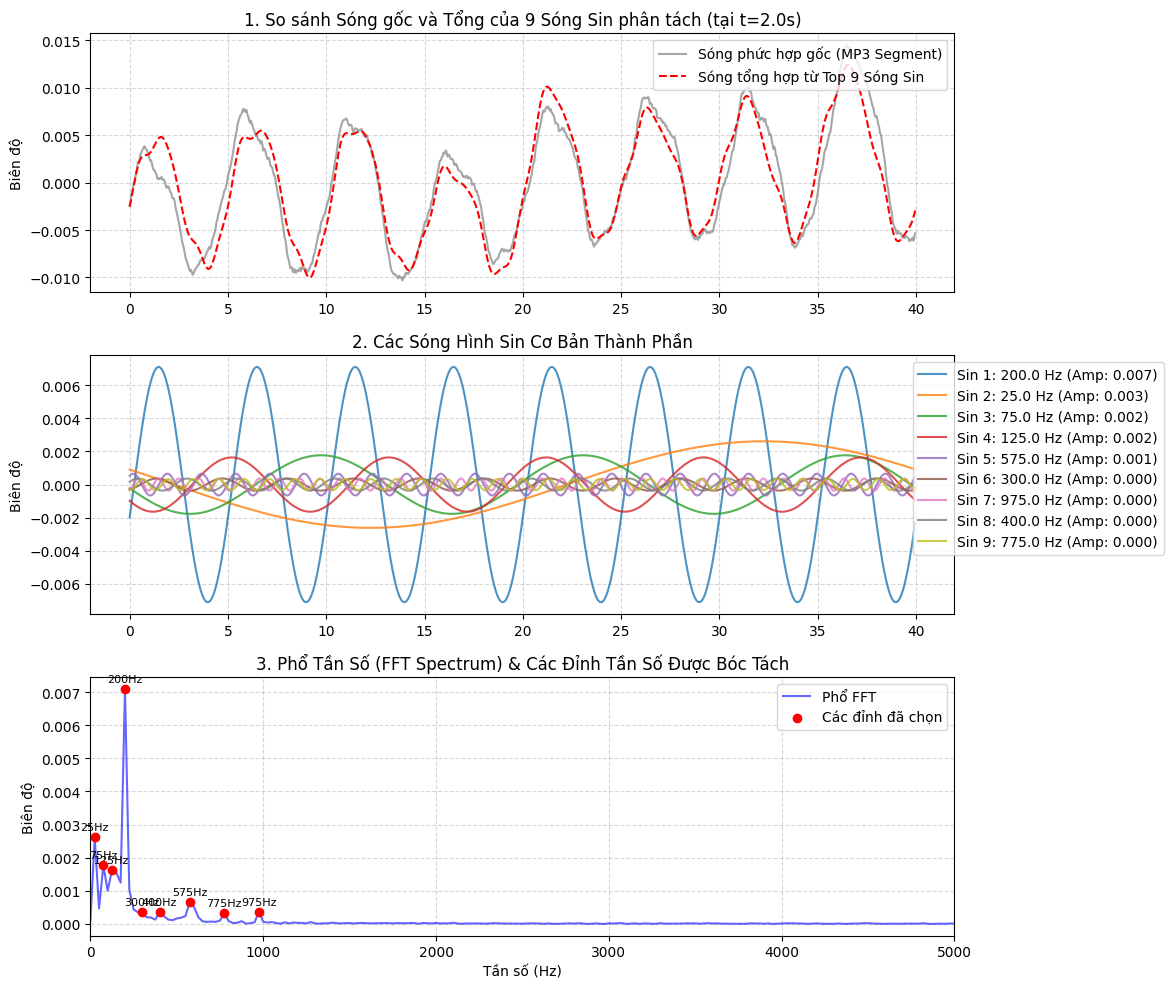

In [8]:
decompose_mp3_to_sines(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3", start_time=2.0, duration=0.04, top_k=100)

In [16]:
from scipy.signal import find_peaks, hilbert
def decompose_and_modulate_envelope(file_path, start_time=1.0, duration=0.04, top_k=20, n_fft=8192):
    """
    Phân tích sóng phức hợp và khắc phục sự lệch biên độ bằng phép biến đổi Hilbert.
    """
    # 1. Load file âm thanh
    y, sr = librosa.load(file_path, sr=None)
    
    start_sample = int(start_time * sr)
    num_samples = int(duration * sr)
    y_segment = y[start_sample : start_sample + num_samples]
    t = np.linspace(0, duration, len(y_segment), endpoint=False)
    
    # 2. Trích xuất ĐƯỜNG BAO BIÊN ĐỘ TỨC THỜI E(t) từ sóng gốc bằng Hilbert Transform
    analytic_signal = hilbert(y_segment)
    instantaneous_envelope = np.abs(analytic_signal)
    
    # 3. Phân tích FFT với Hann Window và Zero-padding
    window = np.hanning(len(y_segment))
    y_windowed = y_segment * window
    fft_result = np.fft.rfft(y_windowed, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1/sr)
    
    magnitudes = np.abs(fft_result) / (np.sum(window) / 2)
    phases = np.angle(fft_result)
    
    # 4. Tìm Top K đỉnh tần số
    min_distance = int(50 / (sr / n_fft))
    peaks, _ = find_peaks(magnitudes, height=np.max(magnitudes) * 0.01, distance=min_distance)
    top_peaks = peaks[np.argsort(magnitudes[peaks])[::-1]][:top_k]
    
    # 5. Tổng hợp sóng sin thô (các sóng sin cộng lại)
    raw_sine_sum = np.zeros_like(t)
    for idx in top_peaks:
        f = freqs[idx]
        amp = magnitudes[idx]
        phase = phases[idx]
        raw_sine_sum += amp * np.cos(2 * np.pi * f * t + phase)
        
    # 6. ĐIỀU CHỈNH BIÊN ĐỘ ĐỘNG:
    # Trích xuất đường bao của chính tổng sóng sin thô để chuẩn hóa
    raw_envelope = np.abs(hilbert(raw_sine_sum))
    raw_envelope[raw_envelope == 0] = 1e-6  # Chống chia cho 0
    
    # Ép sóng tổng hợp đi theo đường bao gốc E(t)
    modulated_sine_sum = (raw_sine_sum / raw_envelope) * instantaneous_envelope
    
    # 7. Trực quan hóa kết quả
    plt.figure(figsize=(12, 6))
    plt.plot(t * 1000000, y_segment, color='gray', alpha=0.6, label='Sóng gốc (MP3 Segment)')
    plt.plot(t * 1000000, instantaneous_envelope, color='blue', linestyle=':', linewidth=1.5, label='Đường bao biên độ E(t) gốc (Hilbert)')
    plt.plot(t * 1000000, raw_sine_sum, color='orange', linestyle='--', alpha=0.5, label='Sóng sin thô (Chưa điều chế)')
    plt.plot(t * 1000000, modulated_sine_sum, color='red', linewidth=1.8, label=f'Sóng đã điều chế biên độ (Top {top_k} Sines)')
    
    plt.title('Khắc phục lệch biên độ bằng Điều chế Đường bao tức thời (Envelope Modulation)')
    plt.xlabel('Thời gian (ms)')
    plt.ylabel('Biên độ')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


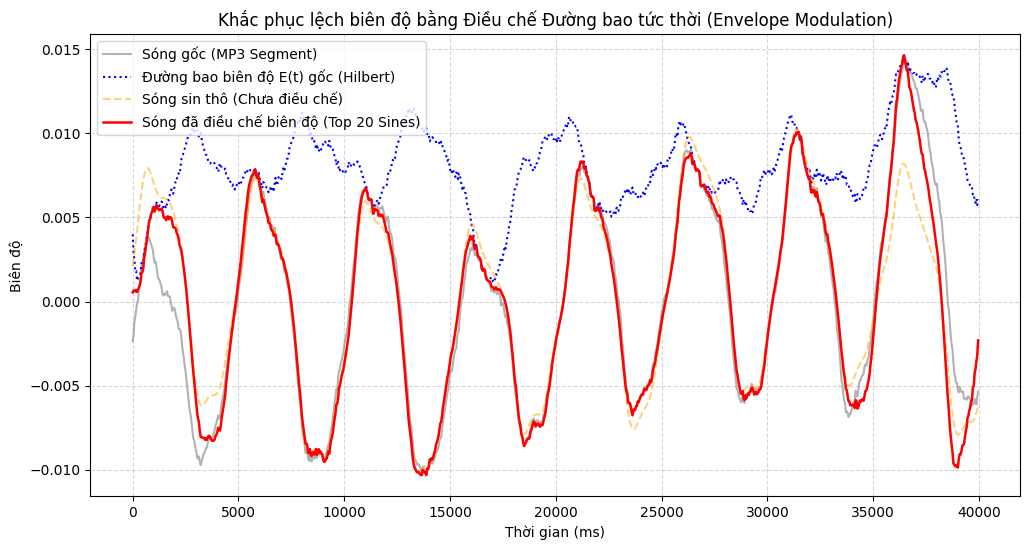

In [17]:
decompose_and_modulate_envelope(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3", 
                         start_time=2.0, top_k=20)

In [ ]:
import librosa
import numpy as np
import scipy.io.wavfile as wavfile
from scipy.signal import find_peaks, hilbert

def reconstruct(file_path, output_path=r"E:\s-recognition\data\complex_sound.wav", top_k=30):
    # 1. Load âm thanh gốc
    y, sr = librosa.load(file_path, sr=None)
    
    # 2. TỰ ĐỘNG TÌM ĐỈNH NĂNG LƯỢNG (Vị trí tiếng Violin phát ra mạnh nhất)
    rms = librosa.feature.rms(y=y)[0]
    peak_frame = np.argmax(rms)
    peak_sample = librosa.frames_to_samples(peak_frame, hop_length=512)
    
    # Trích xuất 80ms xung quanh đỉnh năng lượng để phân tích FFT
    frame_len = int(0.08 * sr)
    start_sample = max(0, peak_sample - frame_len // 4)
    y_segment = y[start_sample : start_sample + frame_len]
    
    # 3. Phân tích FFT chính xác cao (Hann Window + Zero-Padding)
    n_fft = 16384  # Độ phân giải cực cao để bắt đúng nốt G2 (~98Hz)
    window = np.hanning(len(y_segment))
    fft_result = np.fft.rfft(y_segment * window, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1/sr)
    
    magnitudes = np.abs(fft_result) / (np.sum(window) / 2)
    phases = np.angle(fft_result)
    
    # 4. Bóc tách Top K đỉnh họa âm nổi bật
    peaks, _ = find_peaks(magnitudes, height=np.max(magnitudes) * 0.001)
    top_peaks = peaks[np.argsort(magnitudes[peaks])[::-1]][:top_k]
    
    print(f"--- Đã tìm thấy nốt Violin tại vị trí {start_sample/sr:.2f}s ---")
    print(f"Tần số chính (Fundamental f0): {freqs[top_peaks[0]]:.1f} Hz")
    
    # 5. Tổng hợp sóng hình sin trên TOÀN BỘ ĐỘ DÀI FILE GỐC
    t_full = np.linspace(0, len(y) / sr, len(y), endpoint=False)
    raw_sine_sum = np.zeros_like(t_full)
    
    for idx in top_peaks:
        f = freqs[idx]
        amp = magnitudes[idx]
        phase = phases[idx]
        raw_sine_sum += amp * np.cos(2 * np.pi * f * t_full + phase)
        
    # 6. ÉP ĐƯỜNG BAO BIÊN ĐỘ GỐC (Giữ nguyên độ ngắn giật nảy của Spiccato)
    env_original = np.abs(hilbert(y))
    env_sine = np.abs(hilbert(raw_sine_sum))
    env_sine[env_sine == 0] = 1e-6
    
    # Điều chế biên độ động toàn file
    y_reconstructed = (raw_sine_sum / env_sine) * env_original
    
    # 7. Chuẩn hóa và xuất file WAV
    y_normalized = y_reconstructed / np.max(np.abs(y_reconstructed))
    audio_int16 = (y_normalized * 32767).astype(np.int16)
    wavfile.write(output_path, sr, audio_int16)
    
    print(f"-> Đã xuất file tái tạo Violin Spiccato: '{output_path}'")
    return output_path

In [ ]:
reconstruct(r"E:\s-recognition\data\u_df365hdxp7-cinematic-piano-note-362716.mp3", top_k=30)

--- Đã tìm thấy nốt Violin tại vị trí 0.04s ---
Tần số chính (Fundamental f0): 592.2 Hz
-> Đã xuất file tái tạo Violin Spiccato: 'E:\s-recognition\data\complex_sound.wav'


'E:\\s-recognition\\data\\complex_sound.wav'